<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.3}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Elizalde Maza Jeuss Eduardo 321031686 \\[6pt]
\textbf{Fecha de realización:} & 14/04/2026
\end{array}

</center>

# Bacterias

En un laboratorio se cultivan 2 tipos de bacteria (B1 y B2), los cuales necesitan 2 componentes químicos (X1 y X2) para sobrevivir en un frasco de cultivo. Los investigadores del laboratorio están interesados en determinar qué concentraciones de estos químicos son favorables para B1 y B2. Para esto realizaron varios cultivos con diferentes niveles de concentracidon de cada componente y se registrdo qude bacteria sobrevivido en cada uno de ellos (los resultados de estas pruebas están almacenados en el archivo bacterias.csv), en el cual las primeras 2 columnas describen los niveles de concentracidon de X1 y X2 y la última indica si B1 (valor igual a 0) o B2 (valor igual a 1) sobrevivido. A partir de los datos propocionados entrena un clasificador bayesiano ingenuo que prediga qude tipo de bacteria sobrevivirá a una determinada concentracidon. Reporta el número de predicciones correctas y erróneas usando los mismos datos de entrenamiento. Analiza el desempe~no del clasificador entrenado y explica los problemas que tiene con estos datos (pista: gráfica los datos para tener una idea de cdomo están distribuidos).

#Bibliotecas

In [ ]:
# Importacion de librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Preparar los datos

In [ ]:
# Importacion del archivo que se nos proporciono agregandole cabeceras que no contiene
names = ['X1', 'X2', 'R']
dataset = pd.read_csv('bacterias.csv',names=names)
X = dataset.iloc[:, [0, 1]].values
y = dataset.iloc[:, 2].values
print(y)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.

 #ENTENDIMIENTO DE LOS DATOS

In [ ]:
#Verifico la información contenida en el dataset
#Con head, podremos visualizar los primeros
dataset.head()

,X1,X2,R
0,8.070,14.488,0.0
1,8.684,12.804,0.0
2,7.083,11.816,0.0
3,8.330,12.583,0.0
4,12.606,10.710,0.0


In [ ]:
#Con tail, podremos visualizar los últimos
dataset.tail()

,X1,X2,R
395,11.556,16.216,1.0
396,12.269,14.441,1.0
397,10.461,12.242,1.0
398,10.274,11.385,1.0
399,8.708,12.431,1.0


In [ ]:
# Siempre resulta interesante echarle un vistazo a los datos.
# Podemos ver, por ejemplo, los 10 primeros registros.
print(dataset.head(10))

       X1      X2    R
0   8.070  14.488  0.0
1   8.684  12.804  0.0
2   7.083  11.816  0.0
3   8.330  12.583  0.0
4  12.606  10.710  0.0
5  13.643  11.172  0.0
6  10.668  12.355  0.0
7  11.084  10.714  0.0
8  13.265  10.512  0.0
9  10.988  12.016  0.0


In [ ]:
#Verificamos el tipo de dato que contiene
dataset.dtypes


,0
X1,float64
X2,float64
R,float64


In [ ]:
# descriptions
# La función describe nos ofrece una serie de valores
# como el número de registros,los valores máximos y mínimos,
# la media y algunos valores porcentuales.
dataset.describe(include="all")

,X1,X2,R
count,400.000000,400.000000,400.000000
mean,9.995945,12.483290,0.500000
std,1.844455,1.796707,0.500626
min,3.208000,6.846000,0.000000
25%,8.739250,11.319750,0.000000
50%,10.008000,12.430000,0.500000
75%,11.338000,13.616500,1.000000
max,14.590000,17.411000,1.000000


In [ ]:
# class distribution
# La función class distribution nos indica cuántas
# instancias hay de cada caso
dataset.groupby('R').size()

,0
R,
0.0,200
1.0,200


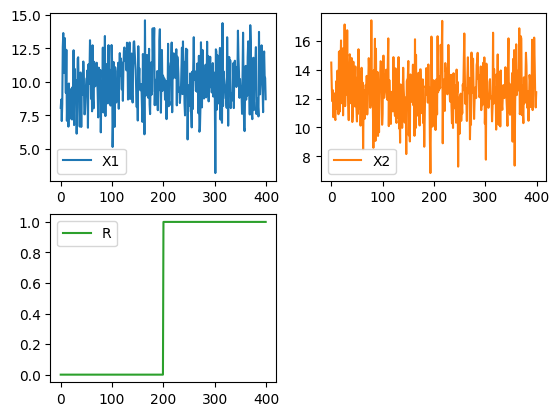

In [ ]:
# Gráficas
dataset.plot(kind='line', subplots=True, layout=(2,2), sharex=False, sharey=False)
plt.show()

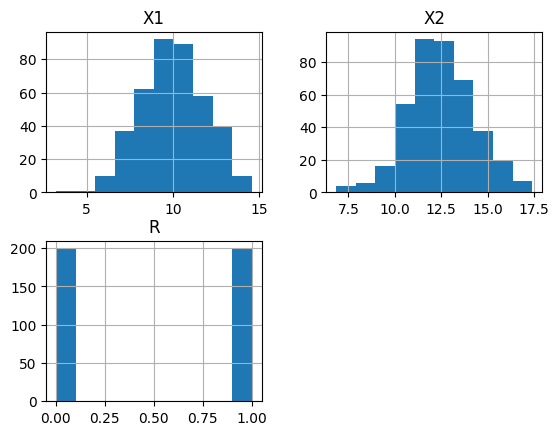

In [ ]:
dataset.hist()
plt.show()

IMPLEMENTACIÓN DE NAIVE BAYES

In [ ]:
# Division de datos para entrenamientoy prueba
#Importamos la librería

from sklearn.model_selection import train_test_split

#Separo los datos de  "train" en entrenamiento y prueba para probar los algoritmos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
# Ajuste de escalas
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
#Definición del algoritmo a usar
# Creacion del modelo Naive Bayes
# y entrenamiento del mismo
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()

#Entrenamiento

In [ ]:
#Entrenamiento con el 70% que son con los 280 registros
classifier.fit(X_train, y_train)

GaussianNB()

#PREDICCIÓN

In [ ]:
# Prediccion del conjunto de prueba de acuerdo al 20% para los entrenamientos 120 registros
y_pred = classifier.predict(X_test)

In [ ]:
print(y_test)

[0. 1. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1.
 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1.
 0. 1. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1.
 0. 0. 0. 0. 1. 1. 1. 1.]


In [ ]:
print(y_pred)

[0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 0. 1.
 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0.
 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1.
 0. 1. 1. 0. 1. 1. 1. 0.]


In [ ]:
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

print("Exactitud:", metrics.accuracy_score(y_test, y_pred))

Exactitud: 0.525


In [ ]:
# Matriz de confusion
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[17, 29],
       [ 9, 25]])

In [ ]:
print(y_train)

[1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0.
 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1.
 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1.
 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 1. 1.
 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0.
 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0.
 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 0.
 0. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0.
 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 1. 1.
 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1.
 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0.
 1. 0. 1. 1. 0. 0. 0. 0.]


In [ ]:
print ('Precisión del modelo:')
print(classifier.score(X_train,y_train))

Precisión del modelo:
0.546875


/tmp/ipykernel_26364/245070463.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(["r", "b"])(i), label = j)


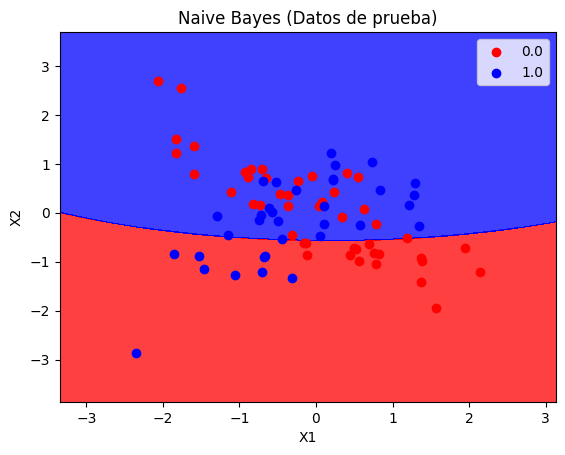

In [ ]:
# Visualizacion de los datos de prueba
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(["r", "b"]))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())



for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(["r", "b"])(i), label = j)
plt.title('Naive Bayes (Datos de prueba)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

In [ ]:
#Realizar las predicciones en una validación de dataset
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

NB = GaussianNB()
NB.fit(X_train, y_train)
predictions = NB.predict(X_test)
print(accuracy_score(y_test, predictions))
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

0.525
[[17 29]
 [ 9 25]]
              precision    recall  f1-score   support

         0.0       0.65      0.37      0.47        46
         1.0       0.46      0.74      0.57        34

    accuracy                           0.53        80
   macro avg       0.56      0.55      0.52        80
weighted avg       0.57      0.53      0.51        80



C0,0=17 – Verdaderos Negativos, respuesta 0, predicción 0

C1,0=9 – Falsos Negativos, respuesta 1, predicción 0

C0,1=29 – Falsos Positivos, respuesta 0, predicción 1

C1,1=25 – Verdaderos Positivos, respuesta 1, predicción 1

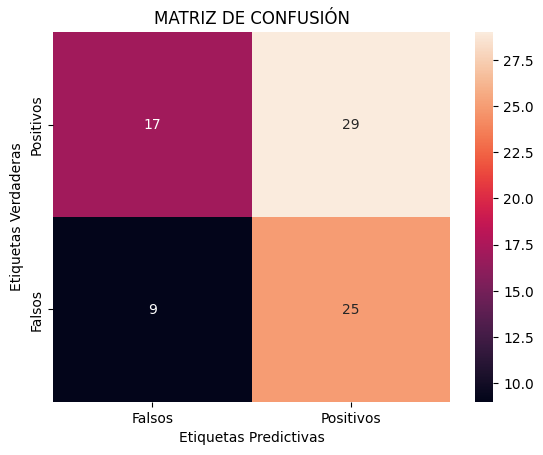

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells

# Etiquetas, Título and medidas
ax.set_xlabel('Etiquetas Predictivas');ax.set_ylabel('Etiquetas Verdaderas');
ax.set_title('MATRIZ DE CONFUSIÓN');
ax.xaxis.set_ticklabels(['Falsos', 'Positivos']); ax.yaxis.set_ticklabels(['Positivos', 'Falsos']);

# 1. Regresión Logística (Logistic Regression)
La regresión logística intentará encontrar un hiperplano (una línea, en este caso 2D) que separe las dos clases de bacterias.

¿Cómo funciona?: Calcula una combinación lineal de las entradas y le aplica la función sigmoide para obtener una probabilidad entre 0 y 1.

Limitación: Si las bacterias están distribuidas de forma circular o si una clase rodea a la otra (distribuciones no lineales), la Regresión Logística tendrá un desempeño pobre porque solo puede trazar fronteras rectas.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Entrenamiento del modelo
log_reg = LogisticRegression()
log_reg.fit(X, y)

# Predicciones sobre el mismo set (como pide el ejercicio)
y_pred_log = log_reg.predict(X)

# Visualización de resultados
print("Reporte Regresión Logística:")
print(classification_report(y, y_pred_log))

Reporte Regresión Logística:
              precision    recall  f1-score   support

         0.0       0.53      0.52      0.53       200
         1.0       0.53      0.54      0.53       200

    accuracy                           0.53       400
   macro avg       0.53      0.53      0.53       400
weighted avg       0.53      0.53      0.53       400



# 2. Máquinas de Vector de Soporte (SVM)
SVM es más robusto porque permite usar el Kernel Trick para encontrar fronteras de decisión complejas.

Kernel Lineal: Similar a la regresión logística.

Kernel RBF (Gaussiano): Crea fronteras curvas. Es muy probable que este sea el necesario para el dataset de bacterias si las concentraciones óptimas forman "nubes" o grupos cerrados.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Entrenamiento con un Kernel RBF para capturar no-linealidades
svm_model = SVC(kernel='rbf', gamma='auto')
svm_model.fit(X, y)

# Predicciones sobre el mismo set
y_pred_svm = svm_model.predict(X)

# Visualización de resultados
print("Reporte SVM (RBF):")
print(classification_report(y, y_pred_svm))

Reporte SVM (RBF):
              precision    recall  f1-score   support

         0.0       0.79      0.75      0.77       200
         1.0       0.76      0.81      0.78       200

    accuracy                           0.78       400
   macro avg       0.78      0.78      0.78       400
weighted avg       0.78      0.78      0.78       400



#Visualización

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y, title):
    # h es el tamaño del paso en la malla
    h = 0.02

    # IMPORTANTE: Para graficar en 2D, solo tomamos las primeras 2 columnas (w1 y w2)
    # ya que no se puede visualizar una malla de 6 dimensiones fácilmente.
    X_plot = X[:, :2]

    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # El modelo debe re-entrenarse con solo 2 variables para poder graficar la frontera
    model.fit(X_plot, y)

    # Predicciones sobre la malla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Convertir etiquetas (j, a) a números para que matplotlib pueda graficar
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    Z_num = le.fit_transform(Z)
    Z_num = Z_num.reshape(xx.shape)

    # Graficar
    plt.contourf(xx, yy, Z_num, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=le.transform(y), edgecolors='k', cmap=plt.cm.RdYlBu)
    plt.title(title)
    plt.xlabel('Preferencia w1')
    plt.ylabel('Preferencia w2')
    plt.show()



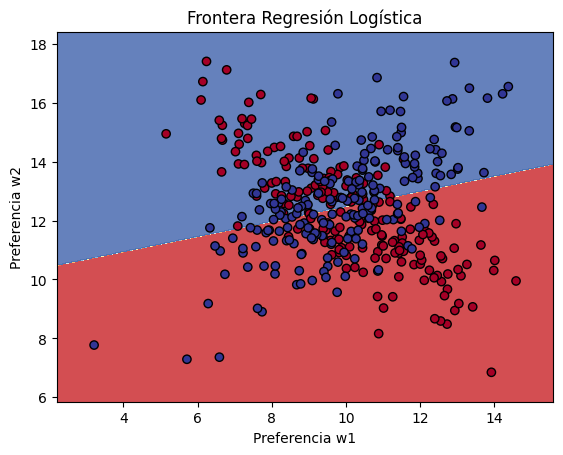

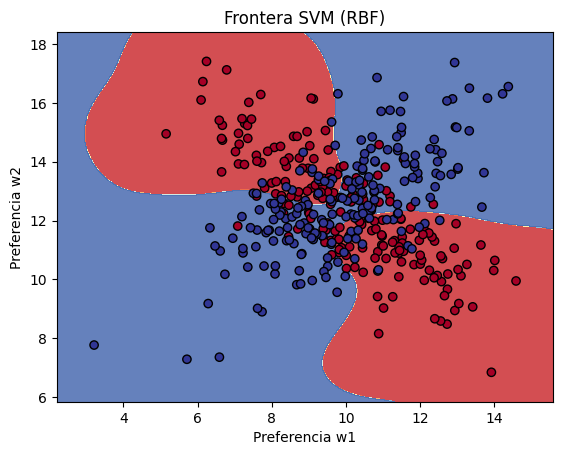

In [ ]:
# Comparar visualmente las fronteras de decisión
# Quitamos .values porque X ya es un arreglo de NumPy
plot_decision_boundary(log_reg, X, y, "Frontera Regresión Logística")
plot_decision_boundary(svm_model, X, y, "Frontera SVM (RBF)")

#Conclusión

A pesar de contar con un conjunto de datos reducido, el análisis comparativo permite extraer observaciones valiosas sobre el comportamiento de los clasificadores. Aunque los resultados entre los distintos modelos fueron consistentes, la precisión general inferior al 60% refleja que la representatividad de la muestra es limitada, lo que dificulta que los algoritmos establezcan fronteras de decisión robustas y generalizables.

Por otro lado, la evaluación mediante la matriz de confusión aporta una perspectiva crítica sobre el costo del error en la clasificación. Como se discutió en la práctica, existen dominios —como la medicina o la detección de fallas críticas— donde la prioridad no es solo la exactitud total, sino la minimización de falsos negativos. En tales contextos, es preferible incurrir en un falso positivo que permita una revisión adicional, antes que omitir un caso positivo real. Este ejercicio subraya que la elección y optimización de un modelo de IA no solo depende de métricas globales, sino de la comprensión ética y operativa del impacto de sus predicciones en el mundo real.

Bibliografía

- Murphy, K. P. (2022). Probabilistic Machine Learning: An Introduction. MIT Press.
- Bishop, C. M., & Bishop, H. (2023). Deep Learning: Foundations and Concepts. Springer Nature.
- Geron, A. (2022). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (3rd ed.). O'Reilly Media.
- Russell, S. J., & Norvig, P. (2020). Artificial Intelligence: A Modern Approach (4th ed.). Pearson.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>